N = 4,  d = 4,  reference run loaded
Zeitschritt 100/100


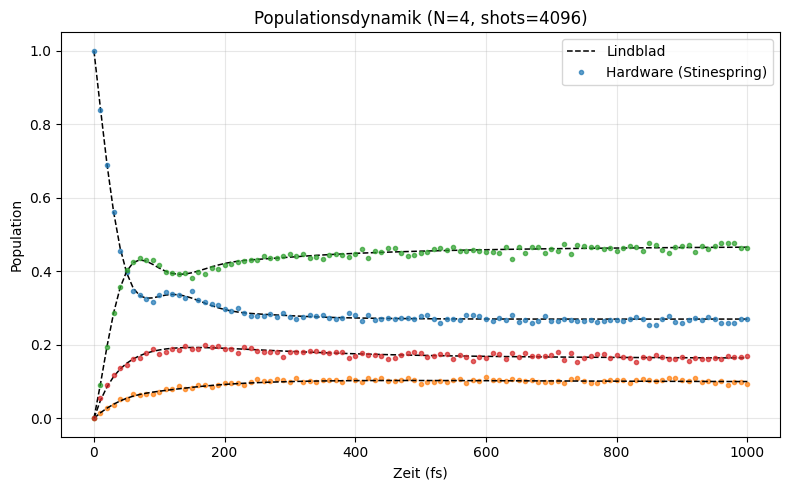

Maximaler Fehler:  0.37806
Mittlerer Fehler:  0.17240


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# -------------------------------------------------
# 1. Hardware-nahe Propagation (viele Shots)
# -------------------------------------------------
def propagate_stinespring_hardware(kraus, d, n_steps, shots=4096, rho0=None):
    U, n_sys, Dp, n_env = stinespring_unitary(kraus, d)
    gate = UnitaryGate(U, label='U')

    if rho0 is None:
        psi0 = np.zeros(Dp, dtype=complex)
        psi0[0] = 1.0
    else:
        psi0 = np.sqrt(np.real(np.diag(rho0)))
        psi0 /= np.linalg.norm(psi0)

    sim = AerSimulator()
    pops = np.zeros((n_steps + 1, d))

    # t = 0
    pops[0, :] = np.abs(psi0[:d])**2

    for t in tqdm(range(1, n_steps + 1), desc="Hardware-Simulation"):
        qc = QuantumCircuit(n_sys + n_env, n_sys)
        qc.initialize(psi0, range(n_sys))

        for _ in range(t):
            qc.append(gate, range(n_sys + n_env))
            qc.reset(range(n_sys, n_sys + n_env))

        qc.measure(range(n_sys), range(n_sys))

        result = sim.run(transpile(qc, sim), shots=shots).result()
        counts = result.get_counts()

        for bitstring, count in counts.items():
            idx = int(bitstring[::-1], 2)
            if idx < d:
                pops[t, idx] += count / shots

    return pops


# -------------------------------------------------
# 2. Beispiel-Aufruf + Vergleich + Plot
# -------------------------------------------------
n_steps = 100          # für den Test erst mal kleiner wählen (1000 dauert lange!)
shots   = 4096

# Hardware-nahe Simulation
pops_hw = propagate_stinespring_hardware(kraus, d, n_steps, shots=shots)

# Exakter Benchmark (dein originaler Code)
pops_exact, _, _ = propagate_stinespring(kraus, d, n_steps)

# -------------------------------------------------
# 3. Plotting
# -------------------------------------------------
times = np.arange(n_steps + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linkes Bild: Populationsdynamik
for i in range(d):
    axes[0].plot(times, pops_exact[:, i], '-',  linewidth=2, label=f'Exact |{i}⟩')
    axes[0].plot(times, pops_hw[:, i],    'o',  markersize=3, alpha=0.6, label=f'Hardware |{i}⟩' if i == 0 else None)

axes[0].set_xlabel('Zeitschritt t')
axes[0].set_ylabel('Population')
axes[0].set_title('Populationsdynamik: Exact vs. Hardware-Simulation')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rechtes Bild: Absoluter Fehler
error = np.abs(pops_hw - pops_exact)
axes[1].plot(times, error, alpha=0.7)
axes[1].set_xlabel('Zeitschritt t')
axes[1].set_ylabel('|p_hw - p_exact|')
axes[1].set_title(f'Absoluter Fehler (shots = {shots})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zusätzliche Zahlen
print(f"Maximaler Fehler:  {np.max(error):.5f}")
print(f"Mittlerer Fehler:  {np.mean(error):.5f}")